# Câncer de mama: o que os dados nos dizem
**Cliente:** hospital · **Base:** 569 aspirações por agulha fina (PAAF), 30 medidas dos núcleos celulares · **Alvo:** `diagnosis` (B = benigno, M = maligno)

Roteiro: (1) distribuição do diagnóstico → (2) distribuição das variáveis numéricas → (3) outliers → (4) correlações → conclusões.

In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)
COR = {"Benigno": "#2a9d8f", "Maligno": "#c1121f"}

df = pd.read_csv("Cancer_Data.csv")
df = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")   # identificador e coluna vazia
df["diagnosis"] = df["diagnosis"].map({"B": "Benigno", "M": "Maligno"})
num = df.select_dtypes("number").columns.tolist()
print(df.shape, "| nulos:", int(df.isna().sum().sum()))

(569, 31) | nulos: 0


## 1. Como estão distribuídas as amostras entre benigno e maligno?

           amostras     %
diagnosis                
Benigno         357  62.7
Maligno         212  37.3


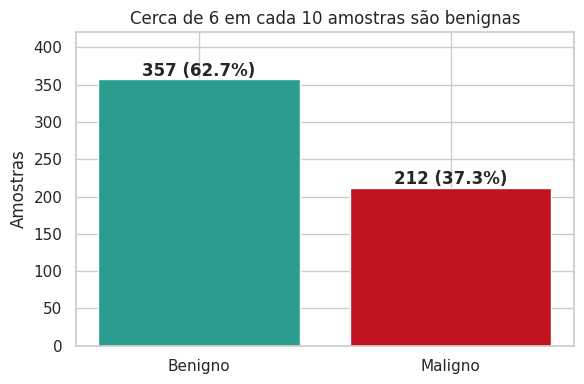

In [3]:
cont = df["diagnosis"].value_counts()
pct = (cont / len(df) * 100).round(1)
print(pd.DataFrame({"amostras": cont, "%": pct}))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(cont.index, cont.values, color=[COR[i] for i in cont.index])
for i, (v, p) in enumerate(zip(cont.values, pct.values)):
    ax.text(i, v + 5, f"{v} ({p}%)", ha="center", fontweight="bold")
ax.set_title("Cerca de 6 em cada 10 amostras são benignas"); ax.set_ylabel("Amostras"); ax.set_ylim(0, 420)
plt.tight_layout(); plt.show()

**Leitura:** 357 benignas (62,7%) e 212 malignas (37,3%). Há desbalanceamento moderado: ao treinar IA, use validação estratificada e avalie por sensibilidade/recall, não só acurácia.

## 2. Como estão distribuídas as variáveis numéricas?

In [4]:
desc = df[num].describe().T
desc["assimetria"] = df[num].skew()
desc.round(3)

,count,mean,std,min,25%,50%,75%,max,assimetria
radius_mean,569.0,14.127,3.524,6.981,11.700,13.370,15.780,28.110,0.942
texture_mean,569.0,19.290,4.301,9.710,16.170,18.840,21.800,39.280,0.650
perimeter_mean,569.0,91.969,24.299,43.790,75.170,86.240,104.100,188.500,0.991
area_mean,569.0,654.889,351.914,143.500,420.300,551.100,782.700,2501.000,1.646
smoothness_mean,569.0,0.096,0.014,0.053,0.086,0.096,0.105,0.163,0.456
compactness_mean,569.0,0.104,0.053,0.019,0.065,0.093,0.130,0.345,1.190
concavity_mean,569.0,0.089,0.080,0.000,0.030,0.062,0.131,0.427,1.401
concave points_mean,569.0,0.049,0.039,0.000,0.020,0.034,0.074,0.201,1.171
symmetry_mean,569.0,0.181,0.027,0.106,0.162,0.179,0.196,0.304,0.726
fractal_dimension_mean,569.0,0.063,0.007,0.050,0.058,0.062,0.066,0.097,1.304


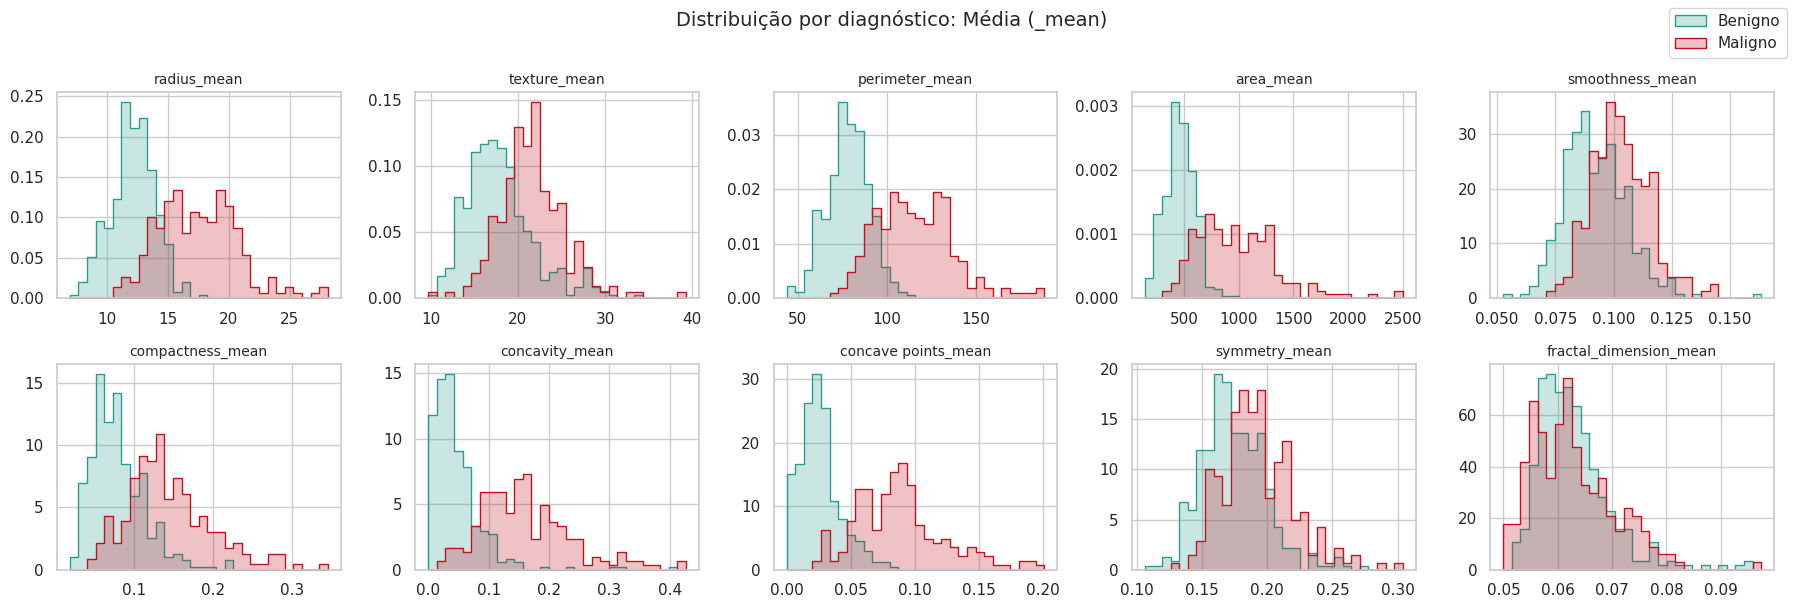

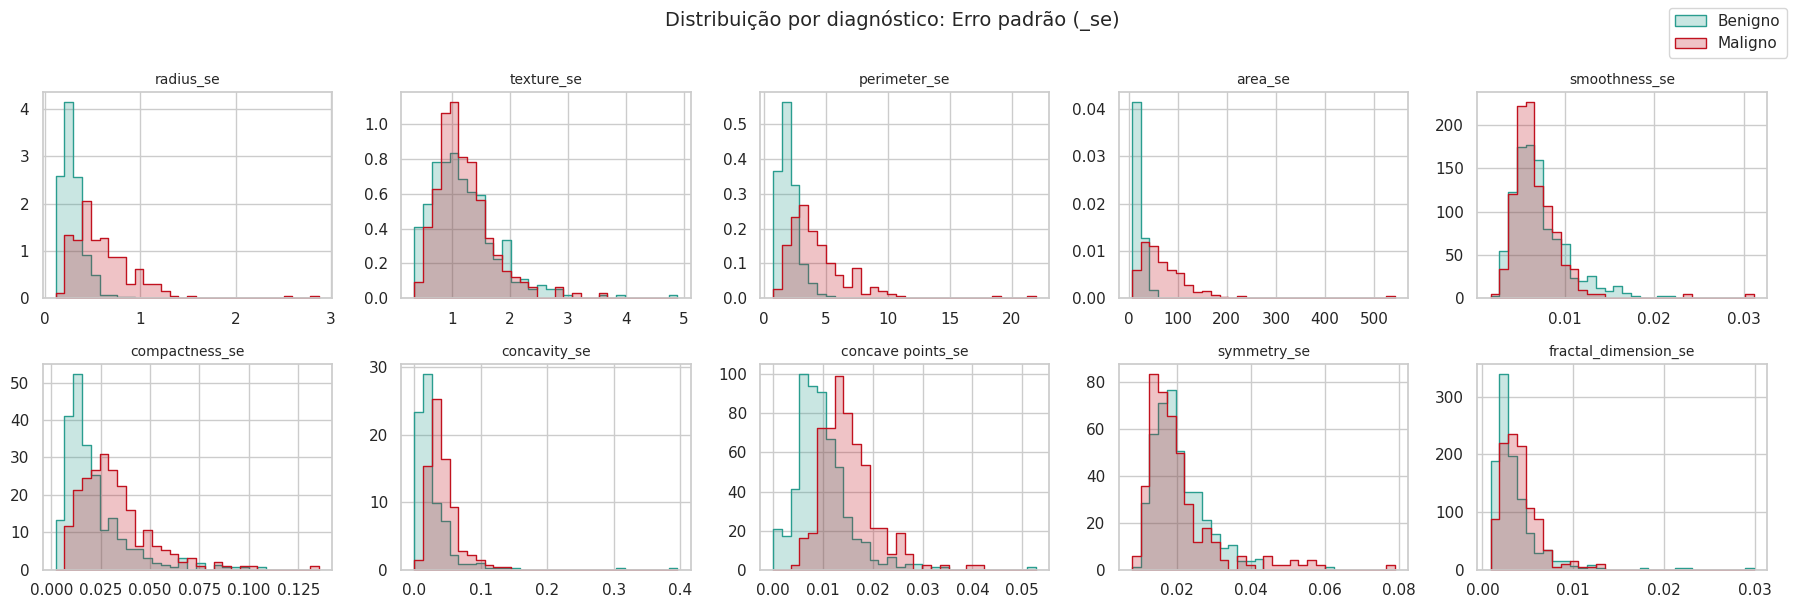

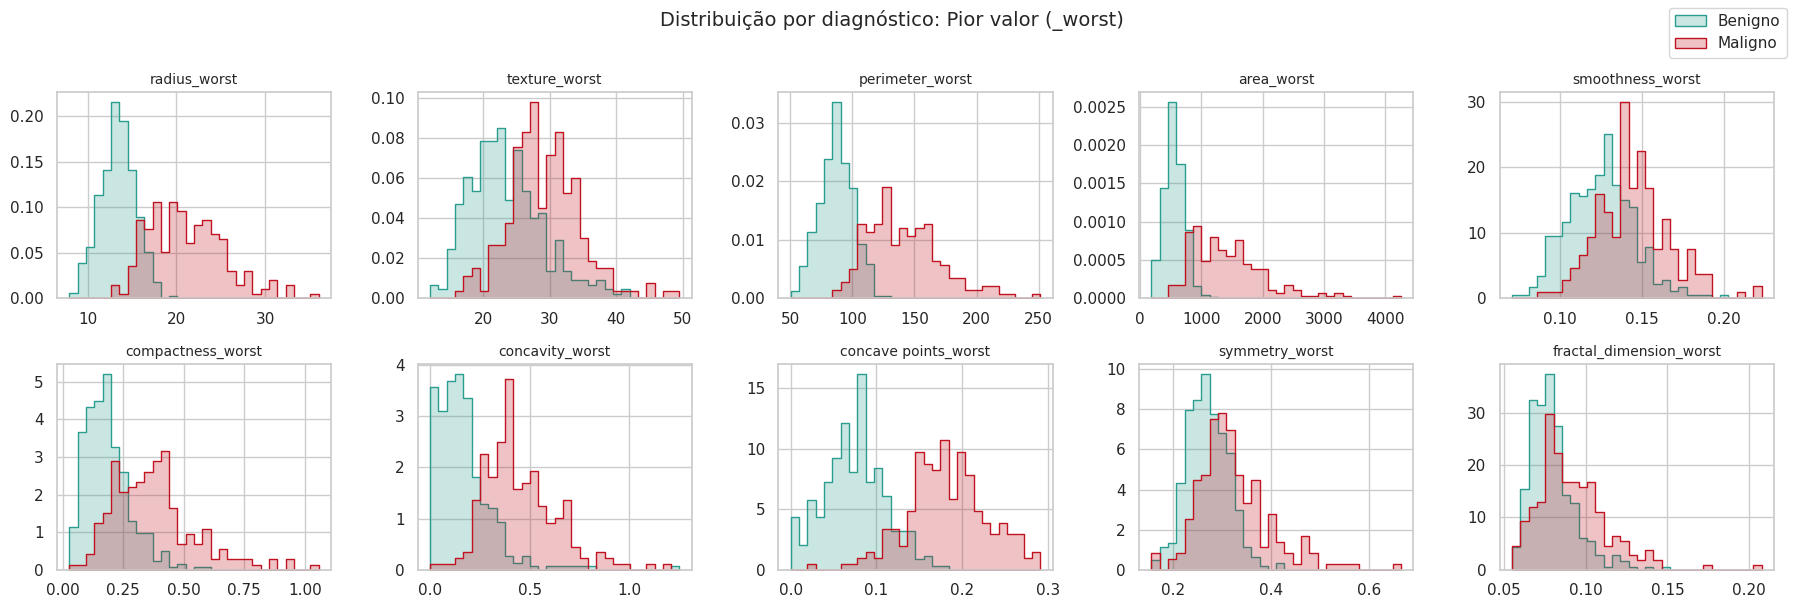

In [5]:
grupos = {"Média (_mean)": [c for c in num if c.endswith("_mean")],
          "Erro padrão (_se)": [c for c in num if c.endswith("_se")],
          "Pior valor (_worst)": [c for c in num if c.endswith("_worst")]}
for nome, cols in grupos.items():
    fig, axes = plt.subplots(2, 5, figsize=(18, 6))
    for ax, c in zip(axes.ravel(), cols):
        sns.histplot(data=df, x=c, hue="diagnosis", palette=COR, bins=30, element="step", stat="density", common_norm=False, ax=ax, legend=False)
        ax.set_title(c, fontsize=10); ax.set_xlabel(""); ax.set_ylabel("")
    fig.suptitle(f"Distribuição por diagnóstico: {nome}", fontsize=14, y=1.01)
    fig.legend(["Benigno", "Maligno"], loc="upper right"); plt.tight_layout(); plt.show()

In [6]:
sk = df[num].skew().sort_values(ascending=False)
print("Variáveis quase simétricas (|assimetria| < 0,5):", int((sk.abs() < 0.5).sum()), "de", len(sk))
print("Mais assimétricas (cauda à direita):"); print(sk.head(5).round(2))

Variáveis quase simétricas (|assimetria| < 0,5): 4 de 30
Mais assimétricas (cauda à direita):
area_se                 5.45
concavity_se            5.11
fractal_dimension_se    3.92
perimeter_se            3.44
radius_se               3.09
dtype: float64


**Leitura:** a maioria das variáveis tem cauda longa à direita (as `_se` são as mais assimétricas, ex.: `area_se` ≈ 5,4). Em quase todas, o grupo maligno se desloca para valores maiores, sobretudo tamanho (raio, perímetro, área) e irregularidade (concavidade, pontos côncavos).

## 3. Quais são os outliers?
Critério: regra de Tukey (fora de Q1 − 1,5·IIQ e Q3 + 1,5·IIQ), por variável.

In [ ]:
q1, q3 = df[num].quantile(.25), df[num].quantile(.75); iqr = q3 - q1
mask = (df[num] < q1 - 1.5*iqr) | (df[num] > q3 + 1.5*iqr)

resumo = pd.DataFrame({"outliers": mask.sum(), "% da coluna": (mask.mean()*100).round(1)}).sort_values("outliers", ascending=False)
print("Pontos fora do padrão:", int(mask.values.sum()), "| Amostras com ao menos 1 outlier:", int(mask.any(axis=1).sum()), f"({mask.any(axis=1).mean()*100:.0f}%)")
print("Por diagnóstico:", mask.any(axis=1).groupby(df["diagnosis"]).sum().to_dict())
resumo.head(10)

Pontos fora do padrão: 608 | Amostras com ao menos 1 outlier: 171 (30%)
Por diagnóstico: {'Benigno': 57, 'Maligno': 114}


,outliers,% da coluna
area_se,65,11.4
radius_se,38,6.7
perimeter_se,38,6.7
area_worst,35,6.2
smoothness_se,30,5.3
fractal_dimension_se,28,4.9
compactness_se,28,4.9
symmetry_se,27,4.7
area_mean,25,4.4
fractal_dimension_worst,24,4.2


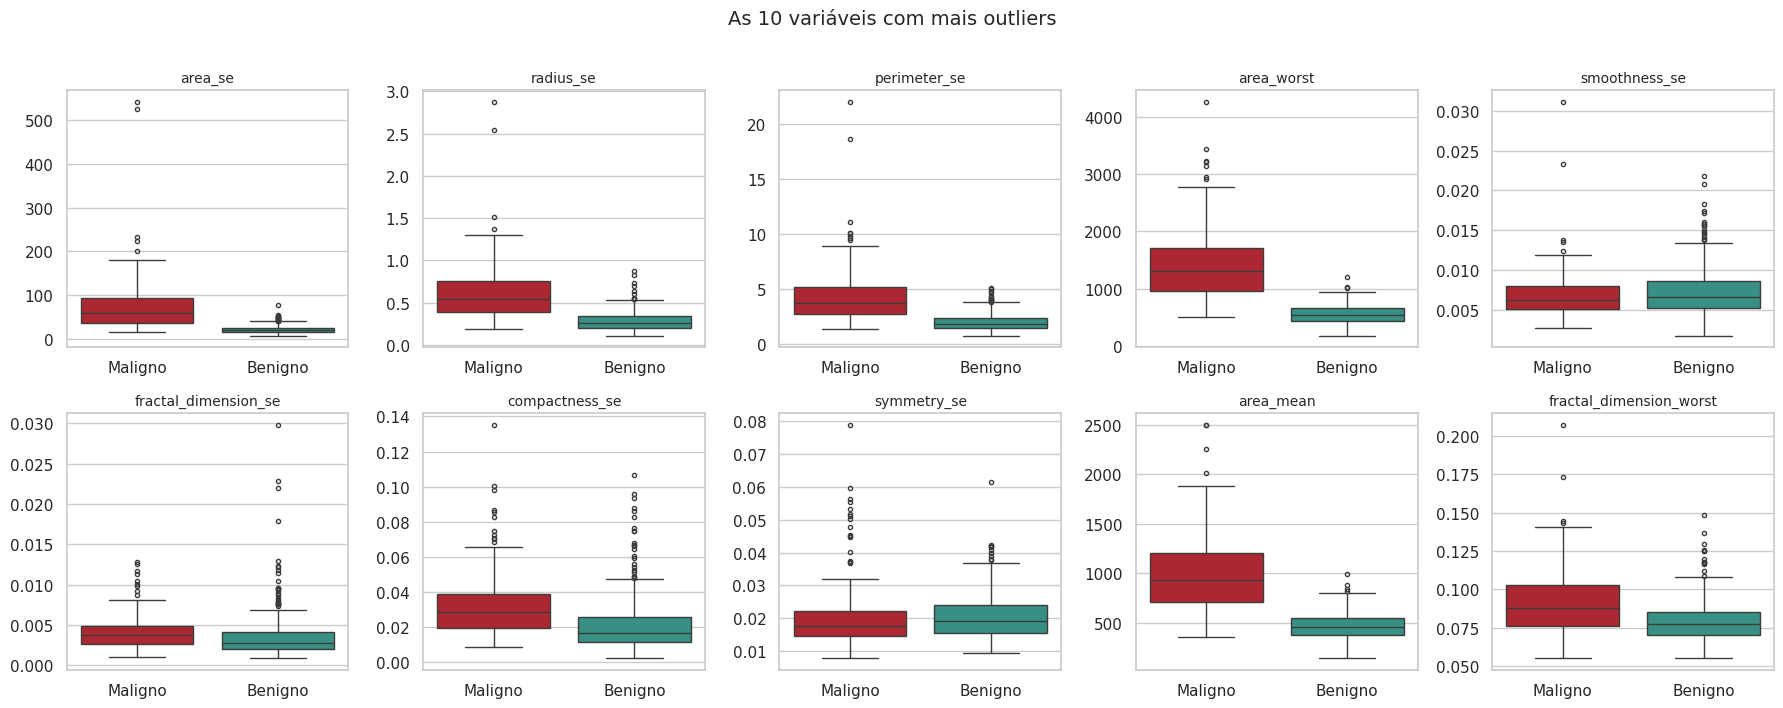

In [ ]:
top = resumo.index[:10]
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, c in zip(axes.ravel(), top):
    sns.boxplot(data=df, x="diagnosis", y=c, hue="diagnosis", palette=COR, legend=False, ax=ax, flierprops=dict(markersize=3))
    ax.set_title(c, fontsize=10); ax.set_xlabel(""); ax.set_ylabel("")
fig.suptitle("As 10 variáveis com mais outliers", fontsize=14, y=1.01); plt.tight_layout(); plt.show()

In [ ]:
# Amostras mais atípicas (mais variáveis fora do padrão), para revisão clínica antes do uso em IA
df["n_outliers"] = mask.sum(axis=1)
df.sort_values("n_outliers", ascending=False)[["diagnosis", "n_outliers", "area_mean", "area_worst", "area_se"]].head(10)

,diagnosis,n_outliers,area_mean,area_worst,area_se
122,Maligno,18,1761.0,2073.0,233.00
108,Maligno,17,1509.0,2360.0,170.00
78,Maligno,13,1245.0,1623.0,116.40
212,Maligno,13,2499.0,2499.0,525.60
352,Maligno,12,2010.0,3234.0,153.10
82,Maligno,12,1878.0,2562.0,120.00
461,Maligno,12,2501.0,4254.0,542.20
3,Maligno,11,386.1,567.7,27.23
12,Maligno,10,1123.0,1332.0,116.20
152,Benigno,10,300.2,380.5,49.85


**Leitura:** 171 amostras (30%) têm ao menos um outlier e **77% dos pontos atípicos estão em casos malignos**. Isso pesa na decisão: tumores grandes e irregulares são clinicamente reais, não erro de medição. **Recomendação:** não removê-los automaticamente. Revisar os mais extremos com a equipe médica e, no modelo, preferir técnicas robustas (árvores, transformação log) a descartar linhas.

## 4. Qual a matriz de correlação?

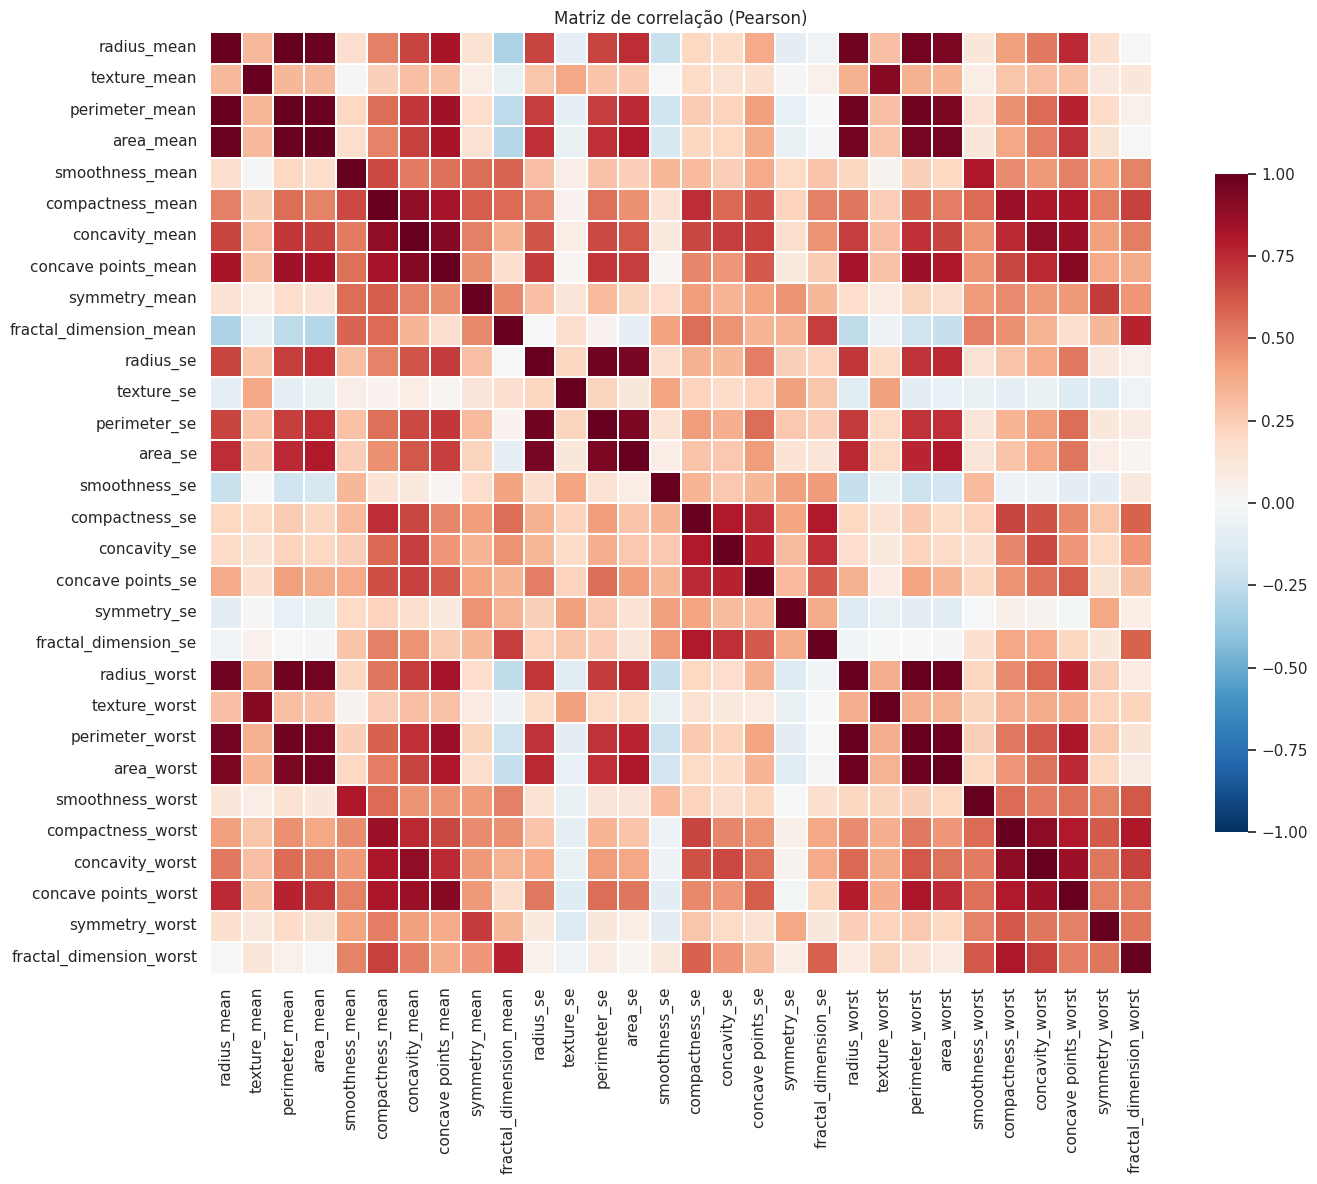

In [ ]:
corr = df[num].drop(columns="n_outliers", errors="ignore").corr()
fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True, linewidths=.3, cbar_kws={"shrink": .7}, ax=ax)
ax.set_title("Matriz de correlação (Pearson)"); plt.tight_layout(); plt.show()

In [ ]:
alvo = (df["diagnosis"] == "Maligno").astype(int)
corr_alvo = df[corr.columns].corrwith(alvo).sort_values(ascending=False)
print("Mais associadas ao diagnóstico maligno:"); print(corr_alvo.head(8).round(2))
print("\nMenos informativas:"); print(corr_alvo.abs().sort_values().head(5).round(2))

pares = (corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack().rename("r").reset_index())
alta = pares[pares["r"].abs() > 0.9].sort_values("r", ascending=False)
print(f"\nPares redundantes (|r| > 0,9): {len(alta)}"); alta.head(8)

Mais associadas ao diagnóstico maligno:
concave points_worst    0.79
perimeter_worst         0.78
concave points_mean     0.78
radius_worst            0.78
perimeter_mean          0.74
area_worst              0.73
radius_mean             0.73
area_mean               0.71
dtype: float64

Menos informativas:
symmetry_se               0.01
texture_se                0.01
fractal_dimension_mean    0.01
smoothness_se             0.07
fractal_dimension_se      0.08
dtype: float64

Pares redundantes (|r| > 0,9): 21


,level_0,level_1,r
2,radius_mean,perimeter_mean,0.997855
622,radius_worst,perimeter_worst,0.993708
3,radius_mean,area_mean,0.987357
63,perimeter_mean,area_mean,0.986507
623,radius_worst,area_worst,0.984015
683,perimeter_worst,area_worst,0.977578
312,radius_se,perimeter_se,0.972794
82,perimeter_mean,perimeter_worst,0.970387


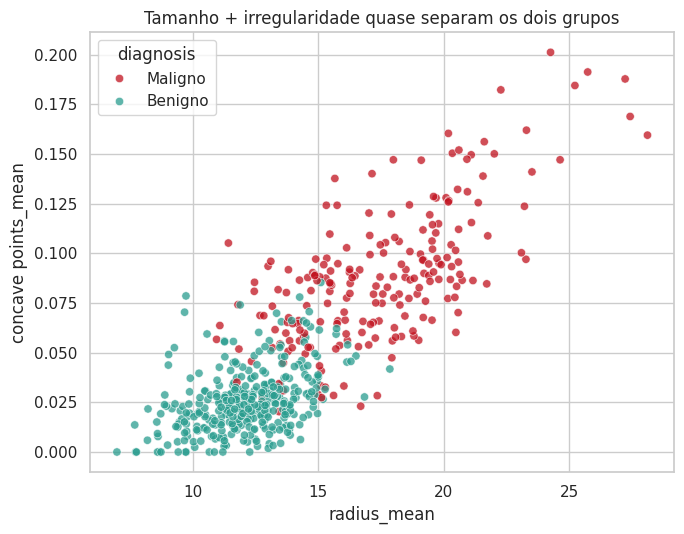

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.scatterplot(data=df, x="radius_mean", y="concave points_mean", hue="diagnosis", palette=COR, alpha=.75, ax=ax)
ax.set_title("Tamanho + irregularidade quase separam os dois grupos"); plt.tight_layout(); plt.show()

**Leitura:**
- **Mais úteis para o alvo:** `concave points_worst`, `perimeter_worst`, `concave points_mean`, `radius_worst` (r ≈ 0,78–0,79).
- **Pouco informativas:** `fractal_dimension_mean`, `texture_se`, `symmetry_se` (|r| ≈ 0).
- **Redundância:** raio, perímetro e área são quase a mesma informação (r > 0,97). Manter **uma** por grupo evita multicolinearidade, e a lista acima de pares com |r| > 0,9 guia a seleção.

## Conclusões para o hospital
1. A base é utilizável, com 37% de casos malignos e sem valores ausentes.
2. Os malignos concentram-se em tamanho e irregularidade nuclear maiores.
3. Outliers são majoritariamente clínicos (malignos): revisar, não apagar.
4. Para a IA, partir de ~6 a 10 variáveis não redundantes, priorizando pontos côncavos, raio/perímetro/área (uma delas) e concavidade.

*Item 5 (dashboard para os médicos): arquivo HTML interativo entregue à parte.*

In [8]:
!pip install sweetviz -q          # no Colab
import sweetviz as sv
df_sv = pd.read_csv("Cancer_Data.csv").drop(columns=["Unnamed: 32"], errors="ignore")
relatorio = sv.analyze(df_sv)
relatorio.show_html("relatorio_sweetviz_cancer.html")

                                             |          | [  0%]   00:00 -> (? left)

Report relatorio_sweetviz_cancer.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
